# MNIST 데이터셋을 활용한 PyTorch 딥러닝 실습

## 코드의 목적

이 코드는 0부터 9까지의 손글씨 숫자 이미지로 구성된 **MNIST 데이터셋**을 사용하여, 입력 이미지가 어떤 숫자인지 분류하는 딥러닝 모델을 학습하는 것이 목적입니다.

PyTorch에서는 기능을 다음과 같이 직접 구현합니다.

- `torchvision.datasets.MNIST`로 MNIST 데이터셋 다운로드 및 로드
- `DataLoader`로 미니 배치 학습 데이터 생성
- `nn.Module` 클래스로 다층 퍼셉트론 모델 정의
- `CrossEntropyLoss`로 다중 분류 손실 계산
- `Adam` 옵티마이저로 가중치 업데이트
- 학습 손실, 검증 손실, 학습 정확도, 검증 정확도 시각화
- 테스트 데이터셋으로 최종 모델 성능 평가



In [1]:
# ============================================================
# 1. 필수 라이브러리 불러오기
# ============================================================

# PyTorch의 핵심 패키지를 불러옵니다.
# Tensor 생성, GPU 연산, 자동 미분 등의 기능을 제공합니다.
import torch

# torch.nn은 신경망 모델을 만들 때 사용하는 레이어, 손실 함수 등을 제공합니다.
import torch.nn as nn

# torch.optim은 Adam, SGD와 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# DataLoader는 데이터를 미니 배치 단위로 나누어 모델에 공급하는 도구입니다.
from torch.utils.data import DataLoader, Subset

# torchvision.datasets는 MNIST와 같은 공개 이미지 데이터셋을 쉽게 불러오는 기능을 제공합니다.
from torchvision import datasets

# torchvision.transforms는 이미지 데이터를 Tensor로 변환하거나 정규화하는 전처리 기능을 제공합니다.
from torchvision import transforms

# NumPy는 배열 계산을 위한 라이브러리입니다.
# 여기서는 학습 결과를 일부 처리하거나 재현성 설정에 사용합니다.
import numpy as np

# matplotlib.pyplot은 학습 손실과 정확도 그래프를 그리기 위해 사용합니다.
import matplotlib.pyplot as plt

# random은 파이썬 기본 난수 생성 라이브러리입니다.
# 재현성 설정에 사용합니다.
import random

In [2]:
# ============================================================
# 2. 실행 환경 및 랜덤 시드 설정
# ============================================================

# 실습 결과가 실행할 때마다 크게 달라지지 않도록 난수 시드를 고정합니다.
# 딥러닝은 가중치 초기화, 데이터 섞기 등에서 난수를 사용하므로 시드 고정이 중요합니다.
SEED = 42

# 파이썬 random 라이브러리의 난수 시드를 고정합니다.
random.seed(SEED)

# NumPy의 난수 시드를 고정합니다.
np.random.seed(SEED)

# PyTorch CPU 연산의 난수 시드를 고정합니다.
torch.manual_seed(SEED)

# CUDA GPU가 사용 가능한 경우 GPU 연산의 난수 시드도 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용하도록 장치를 자동 선택합니다.
# Colab에서 런타임 유형을 GPU로 설정하면 cuda가 선택됩니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 선택된 연산 장치를 출력합니다.
print('사용 장치:', device)

사용 장치: cpu


## 3. MNIST 데이터셋 불러오기

MNIST 데이터셋은 28×28 크기의 손글씨 숫자 이미지와 그 이미지의 정답 라벨로 구성되어 있습니다.

PyTorch에서는 `torchvision.datasets.MNIST`를 사용합니다. 이미지 데이터를 모델에 넣기 위해 `transforms.ToTensor()`를 적용합니다. 이 변환은 이미지를 PyTorch Tensor로 바꾸고 픽셀 값을 0~255 범위에서 0~1 범위로 자동 정규화합니다.

In [3]:
# ============================================================
# 3. MNIST 데이터셋 다운로드 및 전처리 설정
# ============================================================

# transforms.Compose는 여러 전처리 작업을 순서대로 묶어주는 도구입니다.
transform = transforms.Compose([
    # ToTensor는 PIL 이미지 또는 NumPy 배열을 PyTorch Tensor로 변환합니다.
    # MNIST 픽셀 값은 원래 0~255 범위이지만, ToTensor를 거치면 0~1 범위의 float Tensor가 됩니다.
    transforms.ToTensor()
])

# MNIST 훈련 데이터셋을 다운로드하고 불러옵니다.
# root는 데이터가 저장될 폴더입니다.
# train=True는 훈련 데이터 60,000개를 불러온다는 의미입니다.
# download=True는 데이터가 없으면 자동으로 다운로드한다는 의미입니다.
# transform은 위에서 정의한 전처리 방법을 적용한다는 의미입니다.
full_train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# MNIST 테스트 데이터셋을 다운로드하고 불러옵니다.
# train=False는 테스트 데이터 10,000개를 불러온다는 의미입니다.
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 전체 훈련 데이터 개수를 출력합니다.
print('전체 훈련 데이터 개수:', len(full_train_dataset))

# 테스트 데이터 개수를 출력합니다.
print('테스트 데이터 개수:', len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.48MB/s]

전체 훈련 데이터 개수: 60000
테스트 데이터 개수: 10000


In [4]:
# ============================================================
# 4. 훈련 데이터셋과 검증 데이터셋 분리
# ============================================================

# 60,000개의 훈련 데이터 중 앞의 50,000개를 훈련셋으로 사용했습니다.
# 나머지 10,000개는 검증셋으로 사용했습니다.
train_indices = list(range(0, 50000))

# 검증 데이터는 50,000번째부터 59,999번째까지 총 10,000개를 사용합니다.
val_indices = list(range(50000, 60000))

# Subset은 원본 데이터셋에서 지정한 인덱스에 해당하는 데이터만 추출합니다.
train_dataset = Subset(full_train_dataset, train_indices)

# 검증용 데이터셋을 만듭니다.
val_dataset = Subset(full_train_dataset, val_indices)

# 분리된 데이터셋 크기를 출력하여 확인합니다.
print('훈련 데이터 개수:', len(train_dataset))
print('검증 데이터 개수:', len(val_dataset))
print('테스트 데이터 개수:', len(test_dataset))

훈련 데이터 개수: 50000
검증 데이터 개수: 10000
테스트 데이터 개수: 10000


## 4. DataLoader 생성

PyTorch에서는 `DataLoader`를 사용하여 데이터를 미니 배치 단위로 모델에 넣습니다.

훈련 데이터는 매 Epoch마다 순서를 섞는 것이 일반적이므로 `shuffle=True`를 사용합니다. 검증 데이터와 테스트 데이터는 평가용이므로 순서를 섞을 필요가 없습니다.

In [5]:
# ============================================================
# 5. DataLoader 생성
# ============================================================

# 미니 배치 크기를 지정합니다.
BATCH_SIZE = 50

# 훈련 데이터 로더를 생성합니다.
# shuffle=True는 매 Epoch마다 데이터를 섞어 학습 순서에 의한 편향을 줄입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 검증 데이터 로더를 생성합니다.
# 검증은 평가 목적이므로 shuffle=False로 둡니다.
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 테스트 데이터 로더를 생성합니다.
# 테스트도 평가 목적이므로 shuffle=False로 둡니다.
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# DataLoader에서 첫 번째 미니 배치를 꺼내 이미지와 라벨 형태를 확인합니다.
images, labels = next(iter(train_loader))

# images의 형태는 [배치 크기, 채널 수, 높이, 너비]입니다.
# MNIST는 흑백 이미지이므로 채널 수가 1입니다.
print('이미지 배치 형태:', images.shape)

# labels의 형태는 [배치 크기]입니다.
# 각 값은 0~9 중 하나의 정수 라벨입니다.
print('라벨 배치 형태:', labels.shape)

이미지 배치 형태: torch.Size([50, 1, 28, 28])
라벨 배치 형태: torch.Size([50])


## 5. MNIST 이미지 확인

모델을 학습하기 전에 실제 데이터가 어떤 형태인지 확인하는 것이 좋습니다.

아래 코드는 훈련 데이터에서 첫 번째 이미지를 출력하고, 해당 이미지의 정답 라벨도 함께 확인합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


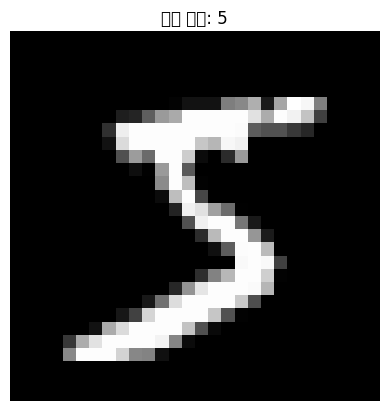

In [6]:
# ============================================================
# 6. MNIST 이미지 시각화
# ============================================================

# 전체 훈련 데이터셋에서 첫 번째 이미지와 정답 라벨을 가져옵니다.
sample_image, sample_label = full_train_dataset[0]

# sample_image의 형태는 [1, 28, 28]입니다.
# matplotlib으로 이미지를 출력하려면 [28, 28] 형태가 편하므로 squeeze()로 채널 차원을 제거합니다.
plt.imshow(sample_image.squeeze(), cmap='gray')

# 그래프 제목에 실제 정답 라벨을 표시합니다.
plt.title(f'정답 라벨: {sample_label}')

# 축 눈금은 이미지 확인에 필요하지 않으므로 숨깁니다.
plt.axis('off')

# 이미지를 화면에 표시합니다.
plt.show()

## 6. PyTorch 모델 정의

PyTorch에서는 `nn.Module` 클래스를 상속하여 같은 구조를 직접 정의합니다.

MNIST 이미지는 28×28 크기이므로 총 784개의 입력값을 가집니다. 따라서 모델에 넣기 전에 이미지를 1차원 벡터로 펼쳐야 합니다.

 PyTorch에서는 마지막 층에 Softmax를 넣지 않는다는 점입니다. `nn.CrossEntropyLoss()`가 내부적으로 Softmax 역할을 포함하기 때문입니다.

In [7]:
# ============================================================
# 7. 다층 퍼셉트론 모델 정의
# ============================================================

# nn.Module은 PyTorch에서 모든 신경망 모델의 기본 클래스입니다.
# 사용자가 직접 모델을 만들 때 이 클래스를 상속받아 사용합니다.
class MNISTMLP(nn.Module):

    # __init__ 메서드는 모델에 필요한 층을 정의하는 부분입니다.
    def __init__(self):

        # 부모 클래스인 nn.Module의 초기화 함수를 호출합니다.
        super(MNISTMLP, self).__init__()

        # nn.Flatten은 [배치 크기, 1, 28, 28] 형태의 이미지를 [배치 크기, 784]로 펼칩니다.
        # MLP는 2차원 이미지 형태가 아니라 1차원 벡터 형태의 입력을 받기 때문입니다.
        self.flatten = nn.Flatten()

        # 첫 번째 완전연결층입니다.
        # 입력 뉴런 수는 28*28=784개이고, 출력 뉴런 수는 512개입니다.
        self.fc1 = nn.Linear(28 * 28, 512)

        # 두 번째 완전연결층입니다.
        # 이전 층의 출력 512개를 입력으로 받아 256개 특징으로 변환합니다.
        self.fc2 = nn.Linear(512, 256)

        # 세 번째 완전연결층입니다.
        # 256개 특징을 128개 특징으로 변환합니다.
        self.fc3 = nn.Linear(256, 128)

        # 출력층입니다.
        # MNIST는 0~9까지 총 10개 클래스를 분류하므로 출력 뉴런 수는 10개입니다.
        self.fc4 = nn.Linear(128, 10)

        # ReLU 활성화 함수입니다.
        # 음수는 0으로 만들고 양수는 그대로 통과시켜 비선형성을 추가합니다.
        self.relu = nn.ReLU()

    # forward 메서드는 입력 데이터가 모델 안에서 어떤 순서로 계산되는지 정의합니다.
    def forward(self, x):

        # 입력 이미지 [배치 크기, 1, 28, 28]을 [배치 크기, 784] 형태로 펼칩니다.
        x = self.flatten(x)

        # 첫 번째 선형층을 통과시킨 후 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc1(x))

        # 두 번째 선형층을 통과시킨 후 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc2(x))

        # 세 번째 선형층을 통과시킨 후 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc3(x))

        # 출력층을 통과시켜 10개 클래스에 대한 점수(logits)를 출력합니다.
        # 여기서는 Softmax를 적용하지 않습니다.
        # CrossEntropyLoss가 내부적으로 Softmax 계산을 포함하기 때문입니다.
        x = self.fc4(x)

        # 최종 출력값을 반환합니다.
        return x

# 정의한 모델 클래스로 실제 모델 객체를 생성합니다.
model = MNISTMLP()

# 모델을 CPU 또는 GPU 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


## 7. 손실 함수와 옵티마이저 설정

PyTorch에서는 손실 함수와 옵티마이저를 직접 변수로 만듭니다.

- `nn.CrossEntropyLoss()` : 다중 분류 문제에서 사용하는 손실 함수
- `optim.Adam()` : 가중치를 효율적으로 업데이트하는 최적화 알고리즘

MNIST는 0~9 중 하나를 맞히는 다중 분류 문제이므로 CrossEntropyLoss가 적합합니다.

In [8]:
# ============================================================
# 8. 손실 함수와 옵티마이저 설정
# ============================================================

# CrossEntropyLoss는 다중 분류 문제에서 많이 사용하는 손실 함수입니다.
# 모델 출력은 [배치 크기, 클래스 수] 형태의 logits이고, 정답은 [배치 크기] 형태의 정수 라벨입니다.
criterion = nn.CrossEntropyLoss()

# Adam 옵티마이저를 생성합니다.
# model.parameters()는 학습해야 할 모든 가중치와 편향을 의미합니다.
# lr=0.001은 학습률이며, 가중치를 한 번에 얼마나 수정할지 결정합니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 전체 데이터를 몇 번 반복 학습할지 지정합니다.
EPOCHS = 10

In [9]:
# ============================================================
# 9. 정확도 계산 함수 정의
# ============================================================

# 정확도를 계산하는 함수를 정의합니다.
# outputs는 모델이 예측한 10개 클래스 점수이고, labels는 실제 정답입니다.
def calculate_accuracy(outputs, labels):

    # torch.max(outputs, dim=1)는 각 행에서 가장 큰 값과 그 위치 인덱스를 반환합니다.
    # 여기서 인덱스가 모델이 예측한 숫자 클래스입니다.
    _, predicted = torch.max(outputs, dim=1)

    # predicted와 labels가 같은지 비교하여 맞힌 개수를 계산합니다.
    correct = (predicted == labels).sum().item()

    # 전체 데이터 개수를 구합니다.
    total = labels.size(0)

    # 맞힌 개수를 전체 개수로 나누어 정확도를 계산합니다.
    accuracy = correct / total

    # 계산된 정확도를 반환합니다.
    return accuracy

## 8. 모델 학습 함수 작성

PyTorch에서는 다음 과정을 직접 작성해야 합니다.

1. 미니 배치 데이터를 모델에 입력한다.
2. 모델의 예측값을 계산한다.
3. 손실 함수를 이용해 오차를 계산한다.
4. 기존 기울기를 초기화한다.
5. 역전파를 수행한다.
6. 옵티마이저가 가중치를 업데이트한다.

이 과정을 모든 미니 배치에 대해 반복하면 1 Epoch 학습이 완료됩니다.

In [10]:
# ============================================================
# 10. 1 Epoch 학습 함수 정의
# ============================================================

# train_one_epoch 함수는 훈련 데이터 전체를 한 번 학습합니다.
def train_one_epoch(model, train_loader, criterion, optimizer, device):

    # model.train()은 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 층이 있을 경우 학습 방식으로 동작합니다.
    model.train()

    # 한 Epoch 동안의 전체 손실을 누적할 변수입니다.
    running_loss = 0.0

    # 한 Epoch 동안의 전체 정확도를 누적할 변수입니다.
    running_acc = 0.0

    # train_loader에서 미니 배치 단위로 이미지와 라벨을 꺼냅니다.
    for images, labels in train_loader:

        # 이미지 데이터를 CPU 또는 GPU 장치로 이동합니다.
        images = images.to(device)

        # 정답 라벨도 같은 장치로 이동합니다.
        labels = labels.to(device)

        # 이전 미니 배치에서 계산된 기울기를 초기화합니다.
        # PyTorch는 기본적으로 기울기를 누적하므로 매 반복마다 초기화가 필요합니다.
        optimizer.zero_grad()

        # 모델에 이미지를 입력하여 예측 결과를 계산합니다.
        outputs = model(images)

        # 예측 결과와 실제 정답을 비교하여 손실값을 계산합니다.
        loss = criterion(outputs, labels)

        # 손실값을 기준으로 역전파를 수행하여 각 가중치의 기울기를 계산합니다.
        loss.backward()

        # 옵티마이저가 계산된 기울기를 이용하여 모델 가중치를 업데이트합니다.
        optimizer.step()

        # 현재 미니 배치의 손실값을 누적합니다.
        running_loss += loss.item()

        # 현재 미니 배치의 정확도를 계산하여 누적합니다.
        running_acc += calculate_accuracy(outputs, labels)

    # 전체 미니 배치 수로 나누어 평균 손실을 계산합니다.
    epoch_loss = running_loss / len(train_loader)

    # 전체 미니 배치 수로 나누어 평균 정확도를 계산합니다.
    epoch_acc = running_acc / len(train_loader)

    # 평균 손실과 평균 정확도를 반환합니다.
    return epoch_loss, epoch_acc

In [11]:
# ============================================================
# 11. 평가 함수 정의
# ============================================================

# evaluate 함수는 검증 데이터 또는 테스트 데이터에 대한 손실과 정확도를 계산합니다.
def evaluate(model, data_loader, criterion, device):

    # model.eval()은 모델을 평가 모드로 전환합니다.
    # 평가 시에는 Dropout 등이 비활성화되어 일관된 결과를 냅니다.
    model.eval()

    # 전체 손실을 누적할 변수입니다.
    running_loss = 0.0

    # 전체 정확도를 누적할 변수입니다.
    running_acc = 0.0

    # 평가 과정에서는 가중치를 업데이트하지 않으므로 기울기 계산을 비활성화합니다.
    # 이렇게 하면 메모리 사용량이 줄고 평가 속도가 빨라집니다.
    with torch.no_grad():

        # data_loader에서 미니 배치 단위로 데이터와 라벨을 꺼냅니다.
        for images, labels in data_loader:

            # 이미지 데이터를 CPU 또는 GPU 장치로 이동합니다.
            images = images.to(device)

            # 정답 라벨도 같은 장치로 이동합니다.
            labels = labels.to(device)

            # 모델에 이미지를 입력하여 예측 결과를 계산합니다.
            outputs = model(images)

            # 예측 결과와 실제 정답을 비교하여 손실값을 계산합니다.
            loss = criterion(outputs, labels)

            # 현재 미니 배치의 손실값을 누적합니다.
            running_loss += loss.item()

            # 현재 미니 배치의 정확도를 계산하여 누적합니다.
            running_acc += calculate_accuracy(outputs, labels)

    # 전체 미니 배치 수로 나누어 평균 손실을 계산합니다.
    epoch_loss = running_loss / len(data_loader)

    # 전체 미니 배치 수로 나누어 평균 정확도를 계산합니다.
    epoch_acc = running_acc / len(data_loader)

    # 평균 손실과 평균 정확도를 반환합니다.
    return epoch_loss, epoch_acc

## 9. 모델 학습 실행

PyTorch에서는 Epoch마다 훈련 함수와 검증 함수를 직접 호출하고, 손실과 정확도를 리스트에 저장합니다. 이 리스트는 나중에 그래프를 그릴 때 사용합니다.

In [12]:
# ============================================================
# 12. 모델 학습 실행
# ============================================================

# Epoch별 훈련 손실을 저장할 리스트입니다.
train_losses = []

# Epoch별 검증 손실을 저장할 리스트입니다.
val_losses = []

# Epoch별 훈련 정확도를 저장할 리스트입니다.
train_accuracies = []

# Epoch별 검증 정확도를 저장할 리스트입니다.
val_accuracies = []

# 지정한 Epoch 수만큼 학습을 반복합니다.
for epoch in range(EPOCHS):

    # 훈련 데이터셋으로 1 Epoch 학습을 수행합니다.
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # 검증 데이터셋으로 현재 모델 성능을 평가합니다.
    val_loss, val_acc = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    # 계산된 훈련 손실을 리스트에 저장합니다.
    train_losses.append(train_loss)

    # 계산된 검증 손실을 리스트에 저장합니다.
    val_losses.append(val_loss)

    # 계산된 훈련 정확도를 리스트에 저장합니다.
    train_accuracies.append(train_acc)

    # 계산된 검증 정확도를 리스트에 저장합니다.
    val_accuracies.append(val_acc)

    # 현재 Epoch의 학습 결과를 출력합니다.
    print(
        f'Epoch [{epoch + 1}/{EPOCHS}] | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val Acc: {val_acc:.4f}'
    )

Epoch [1/10] | Train Loss: 0.2628 | Train Acc: 0.9205 | Val Loss: 0.1290 | Val Acc: 0.9604
Epoch [2/10] | Train Loss: 0.1022 | Train Acc: 0.9685 | Val Loss: 0.0981 | Val Acc: 0.9729
Epoch [3/10] | Train Loss: 0.0656 | Train Acc: 0.9796 | Val Loss: 0.1031 | Val Acc: 0.9702
Epoch [4/10] | Train Loss: 0.0497 | Train Acc: 0.9850 | Val Loss: 0.0885 | Val Acc: 0.9755
Epoch [5/10] | Train Loss: 0.0401 | Train Acc: 0.9875 | Val Loss: 0.0846 | Val Acc: 0.9772
Epoch [6/10] | Train Loss: 0.0332 | Train Acc: 0.9894 | Val Loss: 0.0808 | Val Acc: 0.9785
Epoch [7/10] | Train Loss: 0.0293 | Train Acc: 0.9908 | Val Loss: 0.0837 | Val Acc: 0.9780
Epoch [8/10] | Train Loss: 0.0246 | Train Acc: 0.9925 | Val Loss: 0.0933 | Val Acc: 0.9780
Epoch [9/10] | Train Loss: 0.0222 | Train Acc: 0.9928 | Val Loss: 0.0949 | Val Acc: 0.9785
Epoch [10/10] | Train Loss: 0.0185 | Train Acc: 0.9938 | Val Loss: 0.0904 | Val Acc: 0.9798


## 10. 학습 결과 시각화

PyTorch에서는 학습 과정에서 직접 저장한 리스트인 `train_losses`, `val_losses`, `train_accuracies`, `val_accuracies`를 사용합니다.

일반적으로 좋은 학습 결과는 다음과 같은 형태를 보입니다.

- Loss는 점점 감소하는 것이 좋습니다.
- Accuracy는 점점 증가하는 것이 좋습니다.
- 훈련 정확도는 높지만 검증 정확도가 낮아지면 과적합을 의심할 수 있습니다.

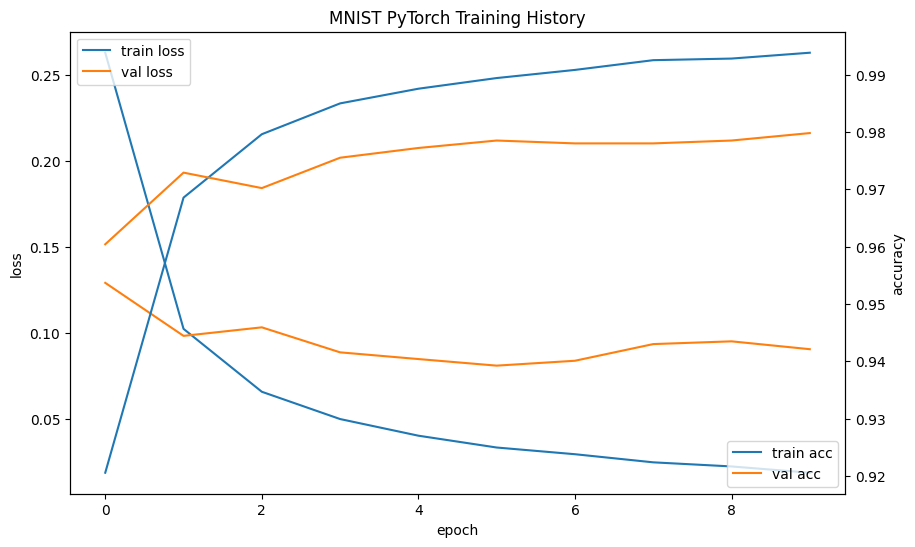

In [13]:
# ============================================================
# 13. 학습 손실과 정확도 그래프 시각화
# ============================================================

# 하나의 그래프 영역을 생성합니다.
fig, loss_ax = plt.subplots(figsize=(10, 6))

# twinx()는 같은 x축을 공유하면서 y축을 하나 더 생성합니다.
# 왼쪽 y축은 손실값, 오른쪽 y축은 정확도를 표시하기 위해 사용합니다.
acc_ax = loss_ax.twinx()

# 훈련 손실 그래프를 그립니다.
loss_ax.plot(train_losses, label='train loss')

# 검증 손실 그래프를 그립니다.
loss_ax.plot(val_losses, label='val loss')

# 훈련 정확도 그래프를 그립니다.
acc_ax.plot(train_accuracies, label='train acc')

# 검증 정확도 그래프를 그립니다.
acc_ax.plot(val_accuracies, label='val acc')

# x축 이름을 설정합니다.
loss_ax.set_xlabel('epoch')

# 왼쪽 y축 이름을 손실값으로 설정합니다.
loss_ax.set_ylabel('loss')

# 오른쪽 y축 이름을 정확도로 설정합니다.
acc_ax.set_ylabel('accuracy')

# 손실 그래프 범례를 왼쪽 위에 표시합니다.
loss_ax.legend(loc='upper left')

# 정확도 그래프 범례를 오른쪽 아래에 표시합니다.
acc_ax.legend(loc='lower right')

# 그래프 제목을 설정합니다.
plt.title('MNIST PyTorch Training History')

# 그래프를 화면에 출력합니다.
plt.show()

## 11. 테스트 데이터셋으로 최종 평가

학습과 검증이 끝난 후에는 테스트 데이터셋으로 최종 성능을 평가합니다.

테스트 데이터는 모델 학습 중 사용하지 않은 데이터이므로, 모델이 새로운 데이터에 대해 얼마나 잘 동작하는지 확인할 수 있습니다.

In [14]:
# ============================================================
# 14. 테스트 데이터셋으로 최종 모델 평가
# ============================================================

# 테스트 데이터셋에 대해 손실과 정확도를 계산합니다.
test_loss, test_acc = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

# 테스트 손실값을 출력합니다.
print(f'Test Loss: {test_loss:.4f}')

# 테스트 정확도를 퍼센트로 변환하여 출력합니다.
print(f'Test Accuracy: {test_acc * 100:.2f}%')

Test Loss: 0.0810
Test Accuracy: 98.12%


## 12. 예측 결과 확인

마지막으로 테스트 이미지 몇 개를 모델에 넣어 실제 정답과 예측 결과를 비교합니다.

모델의 출력값은 10개 클래스에 대한 점수입니다. 이 점수에 `softmax`를 적용하면 각 숫자일 확률로 해석할 수 있습니다.

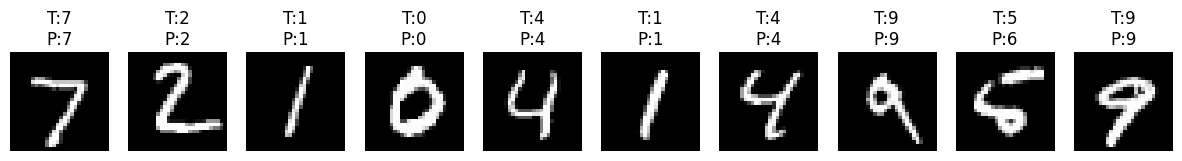

In [15]:
# ============================================================
# 15. 테스트 이미지 예측 결과 확인
# ============================================================

# 모델을 평가 모드로 전환합니다.
model.eval()

# 테스트 데이터 로더에서 첫 번째 미니 배치를 가져옵니다.
test_images, test_labels = next(iter(test_loader))

# 이미지와 라벨을 CPU 또는 GPU 장치로 이동합니다.
test_images = test_images.to(device)
test_labels = test_labels.to(device)

# 평가 과정이므로 기울기 계산을 비활성화합니다.
with torch.no_grad():

    # 테스트 이미지를 모델에 입력하여 출력 점수를 계산합니다.
    outputs = model(test_images)

    # softmax를 적용하여 각 클래스에 대한 확률로 변환합니다.
    probabilities = torch.softmax(outputs, dim=1)

    # 가장 확률이 높은 클래스 인덱스를 예측값으로 선택합니다.
    _, predictions = torch.max(probabilities, dim=1)

# 시각화할 이미지 개수를 지정합니다.
num_images = 10

# 그래프 크기를 설정합니다.
plt.figure(figsize=(15, 4))

# 지정한 개수만큼 이미지를 출력합니다.
for i in range(num_images):

    # 여러 이미지를 한 줄에 배치하기 위해 subplot을 사용합니다.
    plt.subplot(1, num_images, i + 1)

    # i번째 이미지를 CPU로 가져온 뒤 [28, 28] 형태로 변환하여 출력합니다.
    plt.imshow(test_images[i].cpu().squeeze(), cmap='gray')

    # 실제 정답과 예측 결과를 제목으로 표시합니다.
    plt.title(f'T:{test_labels[i].item()}\nP:{predictions[i].item()}')

    # 이미지 축은 숨깁니다.
    plt.axis('off')

# 그래프를 화면에 표시합니다.
plt.show()